<a href="https://colab.research.google.com/github/251711-lab/gghs_media_class/blob/main/%EC%88%98%ED%96%89%ED%8F%89%EA%B0%80_2407_%EC%98%A4%ED%98%95%EC%9E%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import glob
!pip install folium -q
import folium
from folium.plugins import MarkerCluster, FastMarkerCluster
from IPython.display import display

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import matplotlib.pyplot as plt

In [20]:
!pip install koreanize-matplotlib -q
import koreanize_matplotlib

In [21]:
files = glob.glob('/content/drive/MyDrive/**/병원및의원수_의료기관종류별.csv', recursive=True)
df = pd.read_csv(files[0], encoding='cp949')
df.head()

,연도,시도,병의원_종합병원,병의원_요양병원,병의원_일반병원,병의원_의원,특수병원_결핵,특수병원_한센,특수병원_정신,치과병 의원_치과병원,치과병 의원_치과의원,한방병 의원_한방병원,한방병 의원_한의원,부속의원,조산원
0,2015,서울 Seoul,56,102,217,7778,1,0,1,68,4678,39,3540,42,5
1,2015,부산 Busan,28,179,130,2192,0,0,11,19,1206,9,1098,6,4
2,2015,대구 Daegu,12,61,114,1611,0,0,0,17,825,2,841,6,2
3,2015,인천 Incheon,19,60,55,1440,0,0,4,4,830,14,607,4,2
4,2015,광주 Gwangju,22,49,75,887,0,0,0,11,576,84,304,7,0


In [22]:
files2 = glob.glob('/content/drive/MyDrive/**/전국_지역보건의료기관_현황.csv', recursive=True)
df2 = pd.read_csv(files2[0], encoding='cp949')
df2.head()

,시도,시군구,보건기관명,상위기관명,기관유형,대표 전화번호,주소,홈페이지 주소
0,서울특별시,종로구,종로구보건소,NaN,보건소,02-2148-3514,"서울특별시 종로구 자하문로19길 36 (옥인동, 종로구보건소, 청운효자동자치회관) ...",https://www.jongno.go.kr/healthMain.do
1,서울특별시,중구,서울중구보건소,NaN,보건소,02-3396-6302,"서울특별시 중구 다산로39길 16 (무학동, 중구보건소) 중구보건소",http://www.junggu.seoul.kr/health/
2,서울특별시,용산구,용산구보건소,NaN,보건소,02-2199-8350,"서울특별시 용산구 녹사평대로 150 (이태원동, 용산구종합행정타운) 1층 보건소",https://www.yongsan.go.kr/health/main/main.do
3,서울특별시,성동구,성동구보건소,NaN,보건소,02-2286-7115,"서울특별시 성동구 마장로23길 10 (홍익동, 성동구보건소) 성동구보건소",https://www.sd.go.kr/health/index.do
4,서울특별시,광진구,광진구보건소,NaN,보건소,02-450-1422,"서울특별시 광진구 아차산로 400 (자양동, 광진구청) 광진구보건소",https://www.gwangjin.go.kr/health/main/main.do


In [23]:
region_map = {
    '서울특별시':'서울', '부산광역시':'부산', '대구광역시':'대구', '인천광역시':'인천',
    '광주광역시':'광주', '대전광역시':'대전', '울산광역시':'울산', '세종특별자치시':'세종',
    '경기도':'경기', '강원특별자치도':'강원', '충청북도':'충북', '충청남도':'충남',
    '전북특별자치도':'전북', '전라남도':'전남', '경상북도':'경북', '경상남도':'경남',
    '제주특별자치도':'제주'
}

In [24]:
df_2024 = df[df['연도'] == 2024].copy()
df_2024['시도'] = df_2024['시도'].str.split().str[0]   # '서울 Seoul' -> '서울'

cols = ['병의원_종합병원', '병의원_요양병원', '병의원_일반병원', '병의원_의원',
        '특수병원_결핵', '특수병원_한센', '특수병원_정신',
        '치과병 의원_치과병원', '치과병 의원_치과의원',
        '한방병 의원_한방병원', '한방병 의원_한의원', '부속의원', '조산원']
df_2024['민간기관수'] = df_2024[cols].sum(axis=1)

df_2024[['시도', '민간기관수']].head()

,시도,민간기관수
153,서울,19229
154,부산,5545
155,대구,4128
156,인천,3752
157,광주,2302


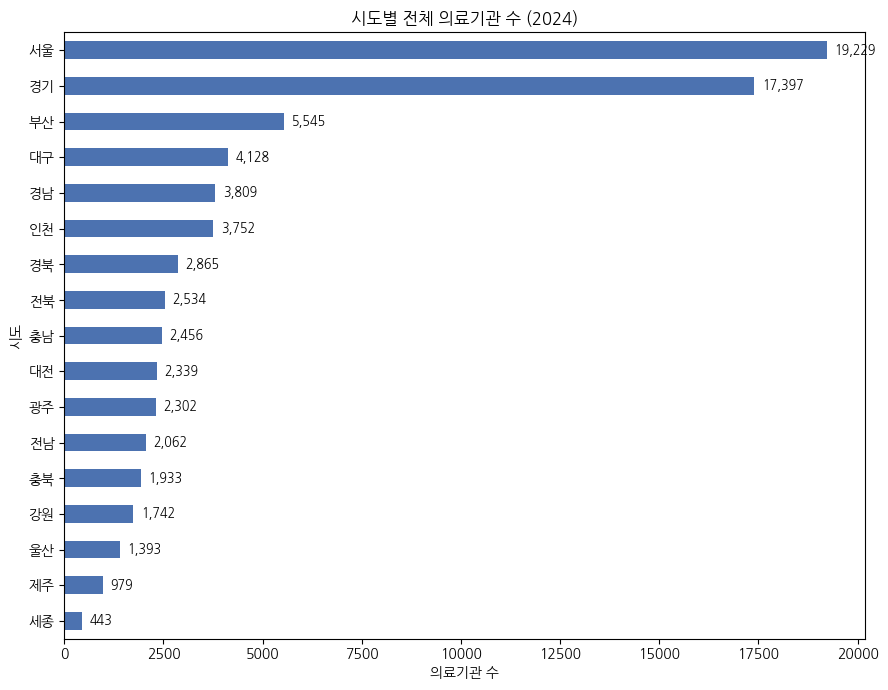

In [25]:
s1 = df_2024.set_index('시도')['민간기관수'].sort_values()

ax1 = s1.plot(
    kind='barh',
    title='시도별 전체 의료기관 수 (2024)',
    figsize=(9, 7),
    color='#4C72B0'
)
ax1.set_xlabel('의료기관 수')

for bar in ax1.patches:
    w = bar.get_width()
    ax1.text(w + s1.max()*0.01, bar.get_y() + bar.get_height()/2,
              f'{int(w):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/시도별_의료기관수_2024.png', dpi=150)
plt.show()

In [26]:
TILE_URL = ('https://server.arcgisonline.com/ArcGIS/rest/services/'
            'World_Imagery/MapServer/tile/{z}/{y}/{x}')

In [27]:
files2 = glob.glob('/content/drive/MyDrive/**/전국_지역보건의료기관_현황.csv',
                   recursive=True)

df2 = pd.read_csv(files2[0], encoding='cp949')

df2.head()

,시도,시군구,보건기관명,상위기관명,기관유형,대표 전화번호,주소,홈페이지 주소
0,서울특별시,종로구,종로구보건소,NaN,보건소,02-2148-3514,"서울특별시 종로구 자하문로19길 36 (옥인동, 종로구보건소, 청운효자동자치회관) ...",https://www.jongno.go.kr/healthMain.do
1,서울특별시,중구,서울중구보건소,NaN,보건소,02-3396-6302,"서울특별시 중구 다산로39길 16 (무학동, 중구보건소) 중구보건소",http://www.junggu.seoul.kr/health/
2,서울특별시,용산구,용산구보건소,NaN,보건소,02-2199-8350,"서울특별시 용산구 녹사평대로 150 (이태원동, 용산구종합행정타운) 1층 보건소",https://www.yongsan.go.kr/health/main/main.do
3,서울특별시,성동구,성동구보건소,NaN,보건소,02-2286-7115,"서울특별시 성동구 마장로23길 10 (홍익동, 성동구보건소) 성동구보건소",https://www.sd.go.kr/health/index.do
4,서울특별시,광진구,광진구보건소,NaN,보건소,02-450-1422,"서울특별시 광진구 아차산로 400 (자양동, 광진구청) 광진구보건소",https://www.gwangjin.go.kr/health/main/main.do


In [28]:
df2.value_counts('시도')

,count
시도,
전라남도,576
경상북도,538
경상남도,423
충청남도,411
전북특별자치도,409
경기도,336
충청북도,271
강원특별자치도,258
인천광역시,74


In [29]:
import requests, re, time, os
import pandas as pd

KAKAO_KEY = '4c52102220aceaa4a6662648ed112281'
headers = {'Authorization': f'KakaoAK {KAKAO_KEY}'}
CACHE = '/content/drive/MyDrive/geocode_cache.csv'

df2 = pd.read_csv(files2[0], encoding='cp949')

def clean_addr(a):
    a = re.sub(r'\(.*?\)', '', str(a))
    m = re.match(r'^(.*?(?:로|길)\s?\d+(?:-\d+)?)', a.strip())
    return (m.group(1) if m else a).strip()

df2['주소_정리'] = df2['주소'].apply(clean_addr)

cache = pd.read_csv(CACHE).set_index('주소_정리').to_dict('index') if os.path.exists(CACHE) else {}

def geocode(addr, name):
    url = 'https://dapi.kakao.com/v2/local/search/address.json'
    r = requests.get(url, headers=headers, params={'query': addr}, timeout=5).json()
    if r.get('documents'):
        d = r['documents'][0]; return float(d['y']), float(d['x'])
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    r = requests.get(url, headers=headers, params={'query': name}, timeout=5).json()
    if r.get('documents'):
        d = r['documents'][0]; return float(d['y']), float(d['x'])
    return None, None

todo = df2.drop_duplicates('주소_정리')
for i, row in enumerate(todo.itertuples(), 1):
    if row.주소_정리 in cache: continue
    lat, lon = geocode(row.주소_정리, row.보건기관명)
    cache[row.주소_정리] = {'lat': lat, 'lon': lon}
    time.sleep(0.05)
    if i % 200 == 0:
        pd.DataFrame.from_dict(cache, orient='index').rename_axis('주소_정리').reset_index().to_csv(CACHE, index=False)

pd.DataFrame.from_dict(cache, orient='index').rename_axis('주소_정리').reset_index().to_csv(CACHE, index=False)

geo = pd.read_csv(CACHE)
df2 = df2.merge(geo, on='주소_정리', how='left')
print('좌표 성공률:', df2['lat'].notna().mean())

좌표 성공률: 0.997782090379817


In [30]:
# ── 지도 그리기: 기관유형별 레이어 + 클러스터 ──────────────
from folium.plugins import MarkerCluster

colors = {'보건소':'red', '보건의료원':'darkred', '건강생활지원센터':'green',
          '일반보건지소':'blue', '통합보건지소':'cadetblue', '보건진료소':'orange'}

# 좌표가 없는 줄은 지도를 그리는 동안만 뺀다 — A 탭 정제 ④단계와 같은 줄
df2 = df2.dropna(subset=['lat', 'lon'])
print(len(df2), '곳')

m = folium.Map(location=[36.5, 127.8], zoom_start=7,
               tiles=TILE_URL, attr='Esri')

# 기관유형마다 겹(FeatureGroup)을 하나씩 만든다 — B 탭 '더 해 보기 ③'과 같은 구조
for gtype, color in colors.items():
    group = folium.FeatureGroup(name=f'{gtype} ({(df2["기관유형"] == gtype).sum()})',
                                  show=(gtype != '보건진료소'))
    cluster = MarkerCluster().add_to(group)   # 뭉치 그릇을 겹 안에 붙인다

    sel = df2[df2['기관유형'] == gtype]
    for _, row in sel.iterrows():
        folium.Marker(
            location=[row['lat'], row['lon']],
            tooltip=row['보건기관명'],
            icon=folium.Icon(color=color)
        ).add_to(cluster)          # ← group이 아니라 cluster에 붙인다

    group.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

3599 곳


In [31]:
public = df2['시도'].value_counts().rename('공공기관수').reset_index()
public.columns = ['시도', '공공기관수']
public['시도'] = public['시도'].map(region_map)

public.head()

,시도,공공기관수
0,전남,573
1,경북,538
2,경남,418
3,충남,411
4,전북,409


In [32]:
merged = df_2024[['시도', '민간기관수']].merge(public, on='시도', how='outer')
merged['공공비율(%)'] = merged['공공기관수'] / merged['민간기관수'] * 100

merged

,시도,민간기관수,공공기관수,공공비율(%)
0,강원,1742,258,14.810563
1,경기,17397,336,1.931367
2,경남,3809,418,10.974009
3,경북,2865,538,18.778360
4,광주,2302,25,1.086012
5,대구,4128,45,1.090116
6,대전,2339,19,0.812313
7,부산,5545,45,0.811542
8,서울,19229,63,0.327630
9,세종,443,19,4.288939


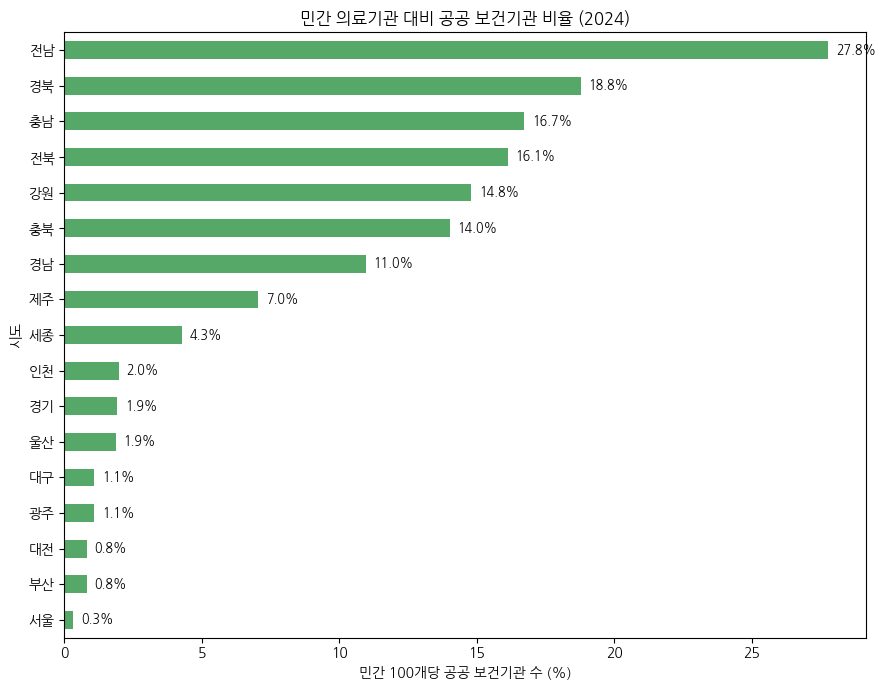

In [33]:
s2 = merged.sort_values('공공비율(%)').set_index('시도')['공공비율(%)']

ax2 = s2.plot(
    kind='barh',
    title='민간 의료기관 대비 공공 보건기관 비율 (2024)',
    figsize=(9, 7),
    color='#55A868'
)
ax2.set_xlabel('민간 100개당 공공 보건기관 수 (%)')

for bar in ax2.patches:
    w = bar.get_width()
    ax2.text(w + s2.max()*0.01, bar.get_y() + bar.get_height()/2,
              f'{w:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/시도별_공공비율_2024.png', dpi=150)
plt.show()